<div style="background-color:#ffecd2; color:#0f0c29; text-align:center; padding:15px; font-size:15px; border-radius:25px;">Polynomial Regression</div>

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)

X = np.random.uniform(-5, 5, 200).reshape(-1, 1)
y = 3*X.squeeze()**2 + 2*X.squeeze() + 5 + np.random.normal(0, 5, 200)
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2)


## Linear Regression

In [3]:
l = LinearRegression()
l.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.83]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,31.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[37.37]


In [4]:
y_pred = l.predict(X_test)
print(f'R^2 Score: ',r2_score(y_test,y_pred))
print(f'MAE:',mean_absolute_error(y_test,y_pred))
print(f'RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))

R^2 Score:  0.03001520612449604
MAE: 18.840903173227726
RMSE:  21.33237076293658


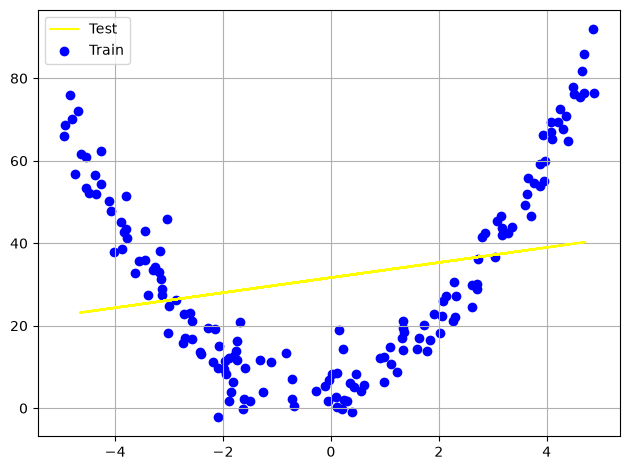

In [5]:
plt.plot(X_test, y_pred,label = 'Test', color = 'yellow')
plt.scatter(X_train,y_train,label = 'Train', color = 'blue')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Polynomial Regression

In [6]:
from sklearn.preprocessing import PolynomialFeatures 

poly  = PolynomialFeatures(degree = 10)
X_train_poly =  poly.fit_transform(X_train)
print(X_train_poly.shape)

(160, 11)


In [7]:
X_train_poly.round()

array([[ 1.00000e+00,  0.00000e+00,  0.00000e+00, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00],
       [ 1.00000e+00,  2.00000e+00,  3.00000e+00, ...,  9.90000e+01,
         1.75000e+02,  3.12000e+02],
       [ 1.00000e+00,  1.00000e+00,  2.00000e+00, ...,  1.00000e+01,
         1.30000e+01,  1.80000e+01],
       ...,
       [ 1.00000e+00, -1.00000e+00,  0.00000e+00, ...,  0.00000e+00,
        -0.00000e+00,  0.00000e+00],
       [ 1.00000e+00, -0.00000e+00,  0.00000e+00, ...,  0.00000e+00,
        -0.00000e+00,  0.00000e+00],
       [ 1.00000e+00, -4.00000e+00,  1.40000e+01, ...,  4.38510e+04,
        -1.66811e+05,  6.34557e+05]], shape=(160, 11))

In [8]:
l1 = LinearRegression()
l1.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0. , 0.47, 0.22,..., 0. ,-0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[23017824.14, 5321262.26, 107248.55,..., 4. , 3.12, 0. ]"


In [9]:
X_test_poly = poly.transform(X_test)


In [10]:
y_pred = l1.predict(X_test_poly)

In [11]:
print('R^2 score: ',r2_score(y_test,y_pred))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))

R^2 score:  0.9677379769993889
RMSE:  3.8904734732075057


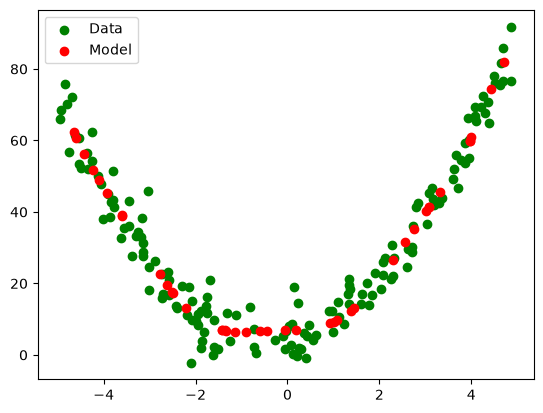

In [12]:
plt.scatter(X_train,y_train, label = 'Data',color = 'green')
plt.scatter(X_test, y_pred,label = 'Model',color ='red')
plt.legend()
plt.show()


In [13]:
def polynomialRegression(X,y,k):
    X_train, X_test , y_train, y_test = train_test_split(X,y, test_size= 0.2,random_state= 42)
    poly = PolynomialFeatures(degree= k)
    X_train_poly = poly.fit_transform(X_train)
    
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)

    X_test_poly = poly.transform(X_test)
    y_pred = lr.predict(X_test_poly)
    training_score = r2_score(y_train, lr.predict(X_train_poly))
    testing_score = r2_score(y_test, y_pred)

    return training_score, testing_score

In [14]:
train = []
test = []
for i in range(1,20):
    r2_train , r2_test = polynomialRegression(X,y, k = i)
    train.append(r2_train)
    test.append(r2_test)

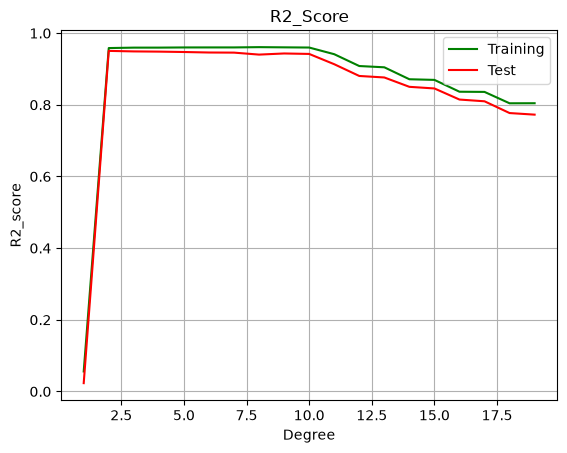

In [15]:
x = np.arange(19) + 1
plt.plot(x, train, label = 'Training',color = 'green')
plt.plot(x, test , label = 'Test',color = 'red')
plt.xlabel('Degree')
plt.ylabel('R2_score')
plt.grid(True)
plt.title('R2_Score')
plt.legend()
plt.show()